In [1]:
import io
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [2]:
import pysam

In [3]:
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [4]:
def get_idxstats(p):
    stats = pd.read_csv(io.StringIO(pysam.idxstats(p)), 
                        sep='\t', 
                        header=None, 
                        names=['chrom', 'length', 'n_mapped', 'n_unmapped'])
    return stats

p_ctr = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/control.mRp.clN.sorted.bam'
p_exp = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/experimental.mRp.clN.sorted.bam'

f_ctr = pysam.AlignmentFile(p_ctr)
f_exp = pysam.AlignmentFile(p_exp)

stats_ctr = get_idxstats(p_ctr)
stats_exp = get_idxstats(p_exp)

n_reads_ctr = stats_ctr.n_mapped.sum()
n_reads_exp = stats_exp.n_mapped.sum()

In [5]:
display(n_reads_ctr)
display(n_reads_exp)

212698794

218623952

In [6]:
# experimental: use all alignments
lens = [
    r.reference_end - r.next_reference_start
    for r in f_exp
    if r.is_reverse and r.is_mapped and r.mate_is_mapped
]

lens = np.array(lens)


# control: use all alignments
lens1 = [
    r.reference_end - r.next_reference_start
    for r in f_ctr
    if r.is_reverse and r.is_mapped and r.mate_is_mapped
]

lens1 = np.array(lens1)

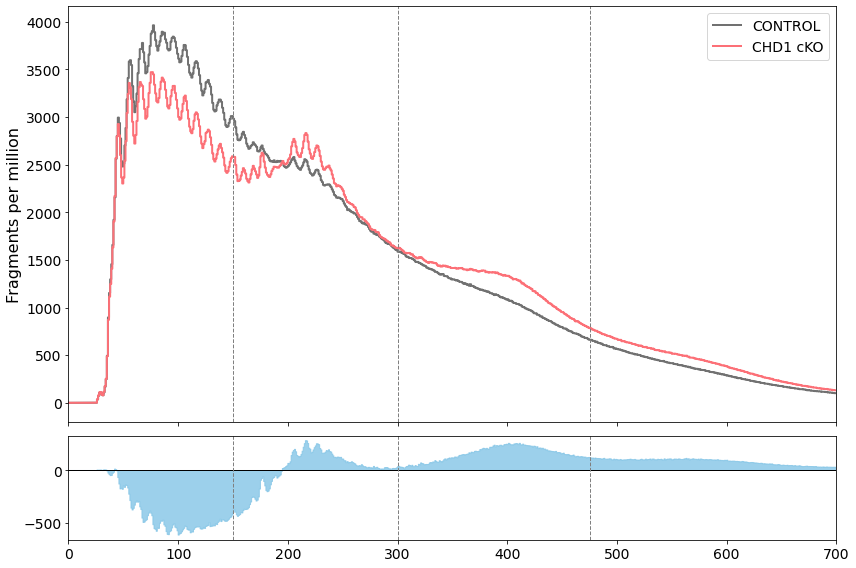

In [7]:
# Distribution of fragment length in the whole genome, merged CONTROL / CHD1 cKO files

figsize = (12, 8)

# build the common histogram 
bin_edges = np.arange(0, 801, 1)  # 1-bp bins
w_ctl = np.ones_like(lens1, dtype=float) * 1000000 / len(lens1) # normalisation per million fragments in the file (Fragments per million)
w_ko  = np.ones_like(lens,  dtype=float) * 1000000 / len(lens)
cnt_ctl, _ = np.histogram(lens1, bins=bin_edges, weights=w_ctl)
cnt_ko,  _ = np.histogram(lens,  bins=bin_edges, weights=w_ko)

diff = cnt_ko - cnt_ctl
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# set up two stacked panels
fig, (ax_main, ax_diff) = plt.subplots(
    2, 1, figsize=figsize, sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # bottom panel narrower
)

# main histograms
ax_main.step(centers, cnt_ctl, where='mid', color='#717171', lw=2, label='CONTROL')
ax_main.step(centers, cnt_ko,  where='mid', color='#FC7077', lw=2, label='CHD1 cKO')

ax_main.set_xlim(0, 700)
ax_main.set_ylabel("Fragments per million", fontsize=16)
ax_main.tick_params(axis='both', labelsize=14)
ax_main.legend(fontsize=14, loc='upper right')
ax_main.grid(False)

# vertical guides
for xpos in [150, 300, 475]:
    ax_main.axvline(xpos, color='gray', linestyle='--', linewidth=1)

# difference curve (bottom panel)
ax_diff.fill_between(centers, diff, 0, step='mid', color='#84C5E6', alpha=0.8)
ax_diff.axhline(0, color='black', linestyle='-', linewidth=1)

# remove axis labels but keep tick labels
ax_diff.set_ylabel("")  # remove y-axis title
ax_diff.set_xlabel("")  # remove x-axis title
ax_diff.tick_params(axis='both', labelsize=14)  # keep tick labels

# vertical guides
for xpos in [150, 300, 475]:
    ax_diff.axvline(xpos, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()

# plt.savefig("/users/uladzis.khauratovich/user_uladzis_khauratovich/pdf_figures_paper_deaft_2025/Fragment_size_whole_genome_fragments.pdf", dpi=300, bbox_inches="tight", pad_inches=1)


In [8]:
def get_idxstats(p):
    stats = pd.read_csv(io.StringIO(pysam.idxstats(p)), 
                        sep='\t', 
                        header=None, 
                        names=['chrom', 'length', 'n_mapped', 'n_unmapped'])
    return stats

chrX_ctr = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/control_chrX_reads.bam'
chrX_exp = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/experimental_chrX_reads.bam'
chr3_ctr = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/control_chr3_reads.bam'
chr3_exp = '/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/vplots/experimental_chr3_reads.bam'

fX_ctr = pysam.AlignmentFile(chrX_ctr)
fX_exp = pysam.AlignmentFile(chrX_exp)
f3_ctr = pysam.AlignmentFile(chr3_ctr)
f3_exp = pysam.AlignmentFile(chr3_exp)

statsX_ctr = get_idxstats(chrX_ctr)
statsX_exp = get_idxstats(chrX_exp)
stats3_ctr = get_idxstats(chr3_ctr)
stats3_exp = get_idxstats(chr3_exp)

n_reads_chrX_ctr = statsX_ctr.n_mapped.sum()
n_reads_chrX_exp = statsX_exp.n_mapped.sum()
n_reads_chr3_ctr = stats3_ctr.n_mapped.sum()
n_reads_chr3_exp = stats3_exp.n_mapped.sum()

In [9]:
display(n_reads_chrX_ctr)
display(n_reads_chrX_exp)
display(n_reads_chr3_ctr)
display(n_reads_chr3_exp)


3747812

7760304

12055388

11919108

In [10]:
lensXe = [r.reference_end - r.next_reference_start 
 for r in fX_exp
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lensXe = np.array(lensXe)

lensXc = [r.reference_end - r.next_reference_start 
 for r in fX_ctr
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lensXc = np.array(lensXc)

lens3e = [r.reference_end - r.next_reference_start 
 for r in f3_exp
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lens3e = np.array(lens3e)

lens3c = [r.reference_end - r.next_reference_start 
 for r in f3_ctr
 if r.is_reverse and r.is_mapped and r.mate_is_mapped]

lens3c = np.array(lens3c)

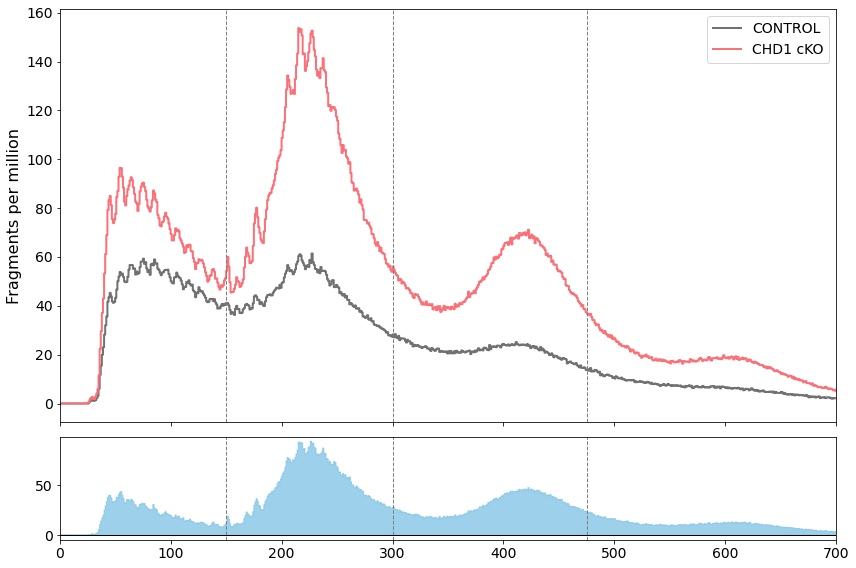

In [11]:
# Distribution of fragment length from Chromosome X, merged CONTROL / CHD1 cKO files

figsize = (12, 8)

# build the common histogram
bin_edges = np.arange(0, 801, 1)  # 1-bp bins
w_ctl = np.ones_like(lensXc, dtype=float) * 1000000 / len(lens1) # normalisation
w_ko  = np.ones_like(lensXe,  dtype=float) * 1000000 / len(lens)
cnt_ctl, _ = np.histogram(lensXc, bins=bin_edges, weights=w_ctl)
cnt_ko,  _ = np.histogram(lensXe,  bins=bin_edges, weights=w_ko)

diff = cnt_ko - cnt_ctl
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# set up two stacked panels
fig, (ax_main, ax_diff) = plt.subplots(
    2, 1, figsize=figsize, sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # bottom panel narrower
)

# main histograms 
ax_main.step(centers, cnt_ctl, where='mid', color='#717171', lw=2, label='CONTROL')
ax_main.step(centers, cnt_ko,  where='mid', color='#FC7077', lw=2, label='CHD1 cKO')

ax_main.set_xlim(0, 700)
ax_main.set_ylabel("Fragments per million", fontsize=16)
ax_main.tick_params(axis='both', labelsize=14)
ax_main.legend(fontsize=14, loc='upper right')
ax_main.grid(False)

# vertical guides
for xpos in [150, 300, 475]:
    ax_main.axvline(xpos, color='gray', linestyle='--', linewidth=1)

# difference curve (bottom panel) 
ax_diff.fill_between(centers, diff, 0, step='mid', color='#84C5E6', alpha=0.8)
ax_diff.axhline(0, color='black', linestyle='-', linewidth=1)

# remove axis labels but keep tick labels
ax_diff.set_ylabel("")  # remove y-axis title
ax_diff.set_xlabel("")  # remove x-axis title
ax_diff.tick_params(axis='both', labelsize=14)  # keep tick labels

# vertical guides
for xpos in [150, 300, 475]:
    ax_diff.axvline(xpos, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()

# plt.savefig("/users/uladzis.khauratovich/user_uladzis_khauratovich/pdf_figures_paper_deaft_2025/Fragment_size_Sex_chromosomes1_fragments_fracton.pdf", dpi=300, bbox_inches="tight", pad_inches=1)


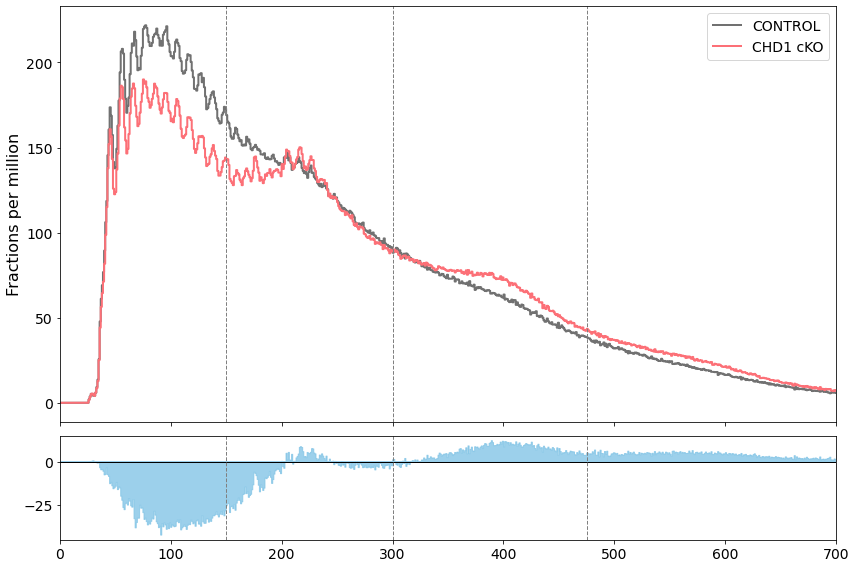

In [12]:
# Distribution of fragment length from Chromosome 3, merged CONTROL / CHD1 cKO files

figsize = (12, 8)

# build the common histogram 
bin_edges = np.arange(0, 801, 1)  # 1-bp bins
w_ctl = np.ones_like(lens3c, dtype=float) * 1000000 / len(lens1)
w_ko  = np.ones_like(lens3e,  dtype=float) * 1000000 / len(lens)
cnt_ctl, _ = np.histogram(lens3c, bins=bin_edges, weights=w_ctl)
cnt_ko,  _ = np.histogram(lens3e,  bins=bin_edges, weights=w_ko)

diff = cnt_ko - cnt_ctl
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# set up two stacked panels 
fig, (ax_main, ax_diff) = plt.subplots(
    2, 1, figsize=figsize, sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}  # bottom panel narrower
)

# main histograms 
ax_main.step(centers, cnt_ctl, where='mid', color='#717171', lw=2, label='CONTROL')
ax_main.step(centers, cnt_ko,  where='mid', color='#FC7077', lw=2, label='CHD1 cKO')

ax_main.set_xlim(0, 700)
ax_main.set_ylabel("Fractions per million", fontsize=16)
ax_main.tick_params(axis='both', labelsize=14)
ax_main.legend(fontsize=14, loc='upper right')
ax_main.grid(False)

# vertical guides
for xpos in [150, 300, 475]:
    ax_main.axvline(xpos, color='gray', linestyle='--', linewidth=1)

# --- 4. difference curve (bottom panel) --------------------------------------
ax_diff.fill_between(centers, diff, 0, step='mid', color='#84C5E6', alpha=0.8)
ax_diff.axhline(0, color='black', linestyle='-', linewidth=1)

# remove axis labels but keep tick labels
ax_diff.set_ylabel("")  # remove y-axis title
ax_diff.set_xlabel("")  # remove x-axis title
ax_diff.tick_params(axis='both', labelsize=14)  # keep tick labels

# vertical guides
for xpos in [150, 300, 475]:
    ax_diff.axvline(xpos, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()

# plt.savefig("/users/uladzis.khauratovich/user_uladzis_khauratovich/pdf_figures_paper_deaft_2025/Fragment_size_chromosome_3_1_FPM.pdf", dpi=300, bbox_inches="tight", pad_inches=1)
